In [1]:
# Let's load some other packages we need
import sys
import os
import pandas as pd
import random
import torch
from torch import nn
from torch import distributions
from torch.nn.parameter import Parameter
# import models
from src.EI_calculation import approx_ei
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nilearn import datasets
#Whether to use cuda or not
# use_cuda = torch.cuda.is_available()
device = torch.device('cuda:8')      

FileNotFoundError: [Errno 2] No such file or directory: './loc_result_stage1/1/stage1/train_loss.csv'

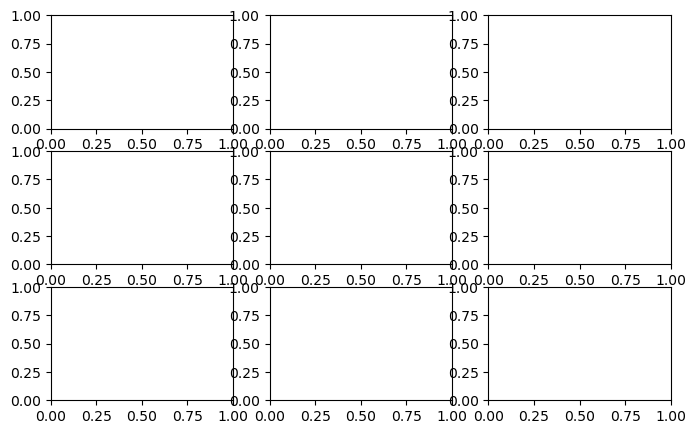

In [2]:
fig,ax1=plt.subplots(3,3, figsize= (8, 5))
scale_number = [32, 16, 8, 4, 2, 1]
for type_name in ['des']:
    for mice_name in [16]:
        for stage_name in [1]:
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            left, right = 0, 0
            train_loss = pd.read_csv('./loc_result_stage1/1/stage%s/train_loss.csv'%(stage_name),header=None)
            test_loss = pd.read_csv('./loc_result_stage1/1/stage%s/test_loss.csv'%(stage_name),header=None)
            train_loss, test_loss = np.array(train_loss), np.array(test_loss)
            for i in range(train_loss.shape[1]):
                ax1[left][right].plot(np.arange(train_loss.shape[0])*1000, train_loss[:,i], label='train_loss')
                ax1[left][right].plot(np.arange(train_loss.shape[0])*1000,test_loss[:,i], label='test_loss')
                ax1[left][right].set_title('scale=%s'%(scale_number[i]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'loss', fontsize=8)
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=6)
                # if left ==0 and right ==0:
                ax1[left][right].legend(fontsize=5)
                right += 1   
                if right %3 == 0:     
                    left += 1       
                    right = 0   
                plt.subplots_adjust(wspace=0.4, hspace=0.9)  

In [ ]:
# diffusion map

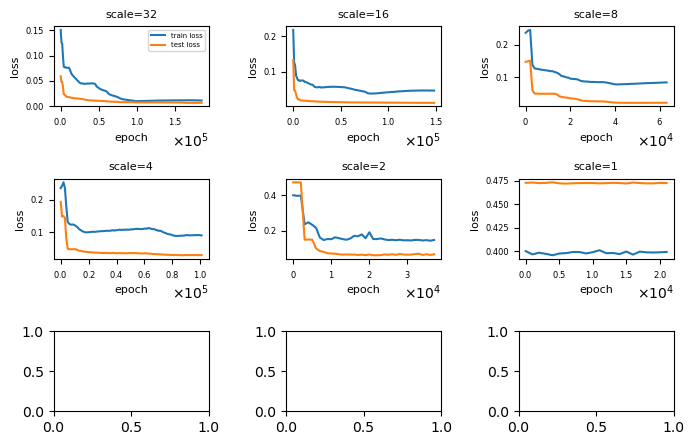

In [3]:
fig,ax1=plt.subplots(3,3, figsize= (8, 5)) 
scale_number = [32, 16, 8, 4, 2, 1]

for type_name in ['des']: 
    for mice_name in [16]:  
        left, right = 0, 0 
        for stage_name in [1]: 
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            for weights in range(0,6): 
                loss1 = pd.read_csv('./loc_result_stage2/stage2_macro/train_loss%s.csv'%(weights),header=None)
                loss2 = pd.read_csv('./loc_result_stage2/stage2_macro/test_loss%s.csv'%(weights),header=None)
                loss1, loss2 = np.array(loss1), np.array(loss2)
                ax1[left][right].plot(np.arange(loss1.shape[0])[:]*1000, loss1[:], label='train loss')
                ax1[left][right].plot(np.arange(loss2.shape[0])[:]*1000, loss2[:], label='test loss')
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                ax1[left][right].set_title('scale=%s'%(scale_number[weights]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'loss', fontsize=8)
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=6)
                if left ==0 and right ==0:
                    ax1[left][right].legend(fontsize=5)
                right += 1 
                if right %3 == 0: 
                    left += 1 
                    right = 0  
                plt.subplots_adjust(wspace=0.5, hspace=0.9)

In [8]:
def moving_average(data, window_size):   
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')  
def cal_data(ei_list):     
    y = ei_list   
    window_size = 3
    y_smooth = np.array([moving_average(y[:,i], window_size) for i in range(y.shape[1])]).T
    new_ei = np.mean(y_smooth[-3:],axis=0) 
    return y_smooth, new_ei    

# stage2

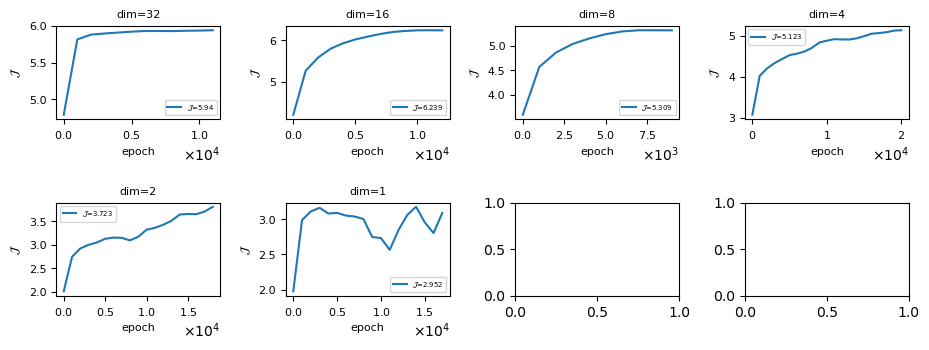

In [9]:
fig,ax1=plt.subplots(2,4, figsize= (11, 3.5))  
scale_number = [32, 16, 8, 4, 2, 1]
ei_all = []  
for type_name in ['des']: 
    for mice_name in [16]:  
        for stage_name in [1]:  
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            left, right = 0, 0 
            for weights in range(6): 
                term1_list1 = pd.read_csv('./loc_result_stage2/1/stage%s/term1_scale%s.csv'%(stage_name,weights),header=None)
                term1_list2 = pd.read_csv('./loc_result_stage2/1/stage%s/term2_scale%s.csv'%(stage_name,weights),header=None)
                term_all = np.array(term1_list1) + np.array(term1_list2)
                smooth_data, ei = cal_data(term_all)
                # ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all, label=r'$\mathcal{J}$')
                ei_all.append(ei[0])
                ax1[left][right].plot(np.arange(smooth_data.shape[0])*1000, smooth_data, label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
                ax1[left][right].set_title('dim=%s'%(scale_number[weights]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=8)    
                # if left ==0 and right ==0:
                # ax1[left][right].set_ylim(0,4)     
                ax1[left][right].legend(fontsize=5)    
                right += 1    
                if right %4 == 0:    
                    left += 1   
                    right = 0   
                plt.subplots_adjust(wspace=0.4, hspace=0.9) 

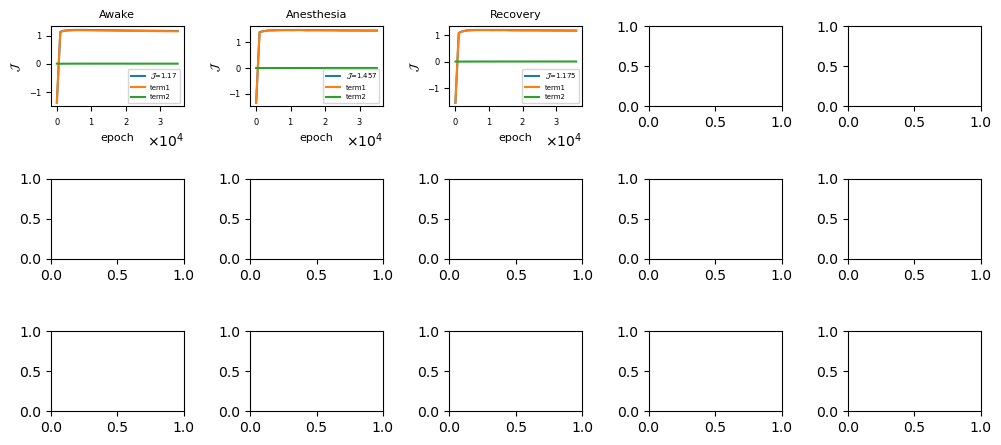

In [4]:
fig,ax1=plt.subplots(3,5, figsize= (12, 5))
stage_list = ['Awake', 'Anesthesia','Recovery']
scale_number = [32,16,8,4,2,1]          
for type_name in ['des']:                 
    for mice_name in [16]:  
        for weights in [0]:  
            ei_stage1, ei_stage2, ei_stage3 = [], [], [] 
            left, right = 0, 0  
            for idx, stage_name in enumerate([1,5,11]): 
                term1_list1 = pd.read_csv('./loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                term1_list2 = pd.read_csv('./loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                term1_list1 = np.array(term1_list1)
                term1_list2 = np.array(term1_list2)
                term_all = term1_list1 + term1_list2
                smooth_data, ei = cal_data(term_all)
                ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all, label=r'$\mathcal{J}$=%s'%(round(ei[0],3)))
                ax1[left][right].plot(np.arange(term1_list1.shape[0])*1000, term1_list1, label=r'term1')
                ax1[left][right].plot(np.arange(term1_list2.shape[0])*1000, term1_list2, label=r'term2')

                ax1[left][right].set_title('%s'%(stage_list[idx]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=6)
                # ax1[left][right].set_ylim(-1,1)
                ax1[left][right].legend(fontsize=5) 
                right += 1                                                                                                                               
                if right %5 == 0:                         
                    left += 1     
                    right = 0         
                plt.subplots_adjust(wspace=0.5, hspace=0.9) 

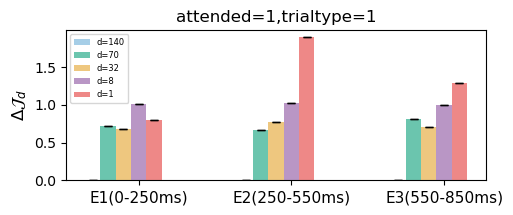

In [6]:
stage_list = ['E1(0-250ms)', 'E2(250-550ms)','E3(550-850ms)'] 

plt.figure(figsize= (5, 2))    
color_list = ['#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']
scale_number = [140, 70, 32, 8, 1]

left, right = 0, 0 
for mice_name in [1]: 
    all_stage_scale = [] 
    for run_time in [2,2]: 
        ei_allstage = []  
        for stage_name in [1, 2, 3]: 
            scale_result = [] 
            for weights in range(0, 5): 
                term1_list1 = pd.read_csv('../Causal-Emergence-of-Consciousness_three_stage%s/loc_result_stage2/%s/stage%s/term1_scale%s.csv'%(run_time,mice_name,stage_name,weights),header=None)
                term1_list2 = pd.read_csv('../Causal-Emergence-of-Consciousness_three_stage%s/loc_result_stage2/%s/stage%s/term2_scale%s.csv'%(run_time,mice_name,stage_name,weights),header=None)
                term1_list1, term1_list2 = np.array(term1_list1), np.array(term1_list2)
                term = term1_list1 + term1_list2 
                _, temp_ei = cal_data(term) 
                scale_result.append(temp_ei[0])
            ei_allstage.append(scale_result)
        ei_new_stage = [] 
        for stage_id in range(len(ei_allstage)):
            # temp_result = [ei_allstage[stage_id][idx] for idx in range(len(ei_allstage[stage_id]))]
            temp_result = [ei_allstage[stage_id][idx]-ei_allstage[stage_id][0] for idx in range(len(ei_allstage[stage_id]))]
            ei_new_stage.append(temp_result)
        ei_all = np.array(ei_new_stage)
        all_stage_scale.append(ei_all)
    all_stage_scale = np.array(all_stage_scale)
    mean_data, std_data = np.mean(all_stage_scale, axis=0), np.std(all_stage_scale, axis=0)
    bar_width = 0.1    
    x = np.arange(len(stage_list))   
    plt.bar(x-2*bar_width, mean_data[:,0], yerr=std_data[:,0], capsize=3, width=bar_width,   color=color_list[0],label='d=140')
    plt.bar(x-1*bar_width, mean_data[:,1], width=bar_width,  yerr=std_data[:,1], capsize=3,color=color_list[1],label='d=70')
    plt.bar(x-0*bar_width, mean_data[:,2], width=bar_width, yerr=std_data[:,2], capsize=3, color=color_list[2],label='d=32')
    plt.bar(x+ bar_width, mean_data[:,3], width=bar_width, yerr=std_data[:,3], capsize=3, color=color_list[3],label='d=8')
    plt.bar(x + 2*bar_width, mean_data[:,4], yerr=std_data[:,4], capsize=3, width=bar_width, color=color_list[4],label='d=1')
                                                                                                                                                                                                                                                                                                                                                                                                                                    
    plt.title('attended=%s,trialtype=%s'%(1, 1), fontsize=12)
    plt.ylabel(r'$\Delta\mathcal{J}_d$', fontsize=12)
    plt.xticks(x + bar_width, stage_list,rotation=0, fontsize=11)
    
    plt.legend(fontsize=6, ncol=1) # , loc='upper center'
    plt.subplots_adjust(wspace=0.2, hspace=0.5, left=0.12,right=0.96,bottom=0.13)
    # plt.savefig('./picture/ce_subject1_attended_%s_trialtype_%s.png'%(1, 1), dpi=300)

([<matplotlib.axis.XTick at 0x7f70bccb4350>,
 [Text(0, 0, '128'),
  Text(1, 0, '64'),
  Text(2, 0, '32'),
  Text(3, 0, '16'),
  Text(4, 0, '8'),
  Text(5, 0, '4'),
  Text(6, 0, '2'),
  Text(7, 0, '1')])

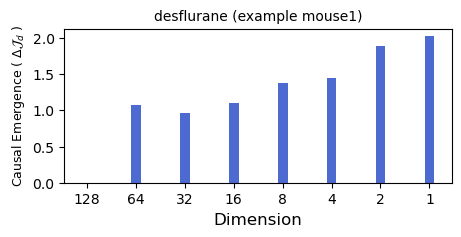

In [4]:
# 定义数据 
plt.figure(figsize= (5, 2))  
left, right = 0, 0  
color_list = ['#4D6AD1','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']

mean_data = [ei_all[idx]-ei_all[0] for idx in range(len(ei_all))]
scale_number = [128,64,32,16,8,4,2,1]
x = np.arange(8)
bar_width = 0.2
plt.bar(x, mean_data,width=bar_width, color=color_list[0], label='d=32')                                                                                                                                                                                                                                                   
plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=10)
plt.xlabel('Dimension', fontsize=12)
plt.ylabel(r'Causal Emergence ( $\Delta$$\mathcal{J}_{d}$ )', fontsize=9)
plt.xticks(x, scale_number,rotation=0, fontsize=10)

# stage3

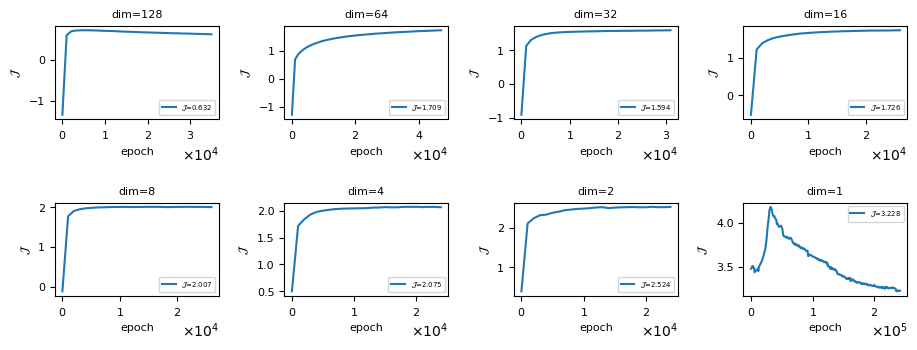

In [16]:
fig,ax1=plt.subplots(2,4, figsize= (11, 3.5))   
scale_number = [128,64,32,16,8,4,2,1]   
ei_all = [] 
for type_name in ['des']: 
    for mice_name in [16]:  
        for stage_name in [1]:  
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            left, right = 0, 0 
            for weights in range(8): 
                if weights == 7:
                    term1_list1 = pd.read_csv('./loc_result_stage3/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage3/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                else:
                    term1_list1 = pd.read_csv('./loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                term_all = np.array(term1_list1) + np.array(term1_list2)
                smooth_data, ei = cal_data(term_all)
                ei_all.append(ei[0])
                if weights == 7:
                    temp_all, _ = cal_data(term_all)
                    ax1[left][right].plot(np.arange(term_all.shape[0]-1)*1000, term_all[1:], label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
                else:
                    ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all[:], label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
                
                ax1[left][right].set_title('dim=%s'%(scale_number[weights]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=8)    
                # if left ==0 and right ==0:    
                ax1[left][right].legend(fontsize=5)    
                right += 1    
                if right %4 == 0:    
                    left += 1   
                    right = 0   
                plt.subplots_adjust(wspace=0.4, hspace=0.9) 

([<matplotlib.axis.XTick at 0x7f70bc896690>,
 [Text(0, 0, '128'),
  Text(1, 0, '64'),
  Text(2, 0, '32'),
  Text(3, 0, '16'),
  Text(4, 0, '8'),
  Text(5, 0, '4'),
  Text(6, 0, '2'),
  Text(7, 0, '1')])

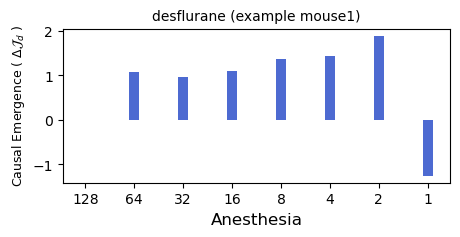

In [6]:
# 定义数据 
plt.figure(figsize= (5, 2))  
left, right = 0, 0  
color_list = ['#4D6AD1','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']

mean_data = [ei_all[idx]-ei_all[0] for idx in range(len(ei_all))]
scale_number = [128,64,32,16,8,4,2,1]
x = np.arange(8)
bar_width = 0.2
plt.bar(x, mean_data,width=bar_width, color=color_list[0], label='d=32')                                                                                                                                                                                                                                                   
plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=10)
plt.xlabel('Anesthesia', fontsize=12)
plt.ylabel(r'Causal Emergence ( $\Delta$$\mathcal{J}_{d}$ )', fontsize=9)
plt.xticks(x, scale_number,rotation=0, fontsize=10)

# stage4

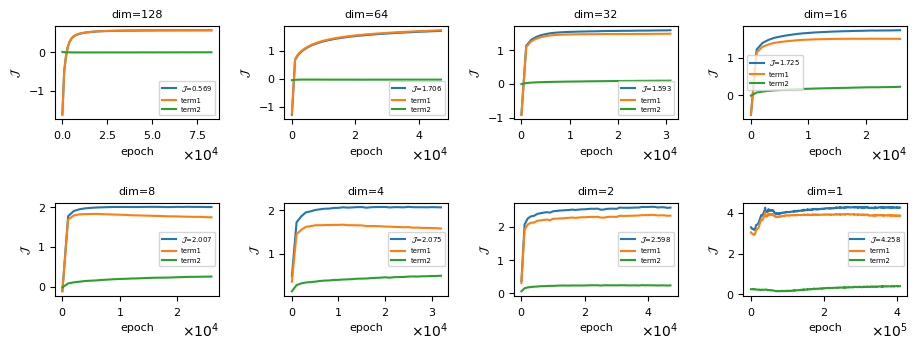

In [13]:
fig,ax1=plt.subplots(2,4, figsize= (11, 3.5))  
scale_number = [128,64,32,16,8,4,2,1] 
ei_all = [] 
for type_name in ['des']:  
    for mice_name in [16]:  
        for stage_name in [1]:  
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            left, right = 0, 0 
            for weights in range(8): 
                if weights == 7: 
                    term1_list1 = pd.read_csv('./loc_result_stage4/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage4/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                
                elif weights == 0: 
                    term1_list1 = pd.read_csv('./loc_result_stage6/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage6/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                else:
                    term1_list1 = pd.read_csv('../Causal-Emergence-of-Consciousness-in-Mice_run1/loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('../Causal-Emergence-of-Consciousness-in-Mice_run1/loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                
                term1_list1 = np.array(term1_list1)
                term1_list2 = np.array(term1_list2)
                term_all = term1_list1 + term1_list2
                smooth_data, ei = cal_data(term_all)
                ei_all.append(ei[0])
                if weights == 7:
                    temp_all, _ = cal_data(term_all)
                    ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all[:], label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
                    ax1[left][right].plot(np.arange(term1_list1.shape[0])*1000, term1_list1[:], label=r'term1')
                    ax1[left][right].plot(np.arange(term1_list2.shape[0])*1000, term1_list2[:], label=r'term2')

                else:
                    ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all[:], label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
                    ax1[left][right].plot(np.arange(term1_list1.shape[0])*1000, term1_list1[:], label=r'term1')
                    ax1[left][right].plot(np.arange(term1_list2.shape[0])*1000, term1_list2[:], label=r'term2')
                    
                ax1[left][right].set_title('dim=%s'%(scale_number[weights]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=8)    
                # if left ==0 and right ==0:
                # ax1[left][right].set_ylim(0,4.8)    
                ax1[left][right].legend(fontsize=5)    
                right += 1    
                if right %4 == 0:    
                    left += 1   
                    right = 0   
                plt.subplots_adjust(wspace=0.4, hspace=0.9) 

[[0.         0.12506438 0.58926357 0.5414705  0.44405295 0.7636564
  1.02828639 1.70236153]
 [0.         0.3537521  0.42235127 0.23350389 0.15054217 0.35908903
  0.78824928 1.27024489]
 [0.         0.21560905 0.64984934 0.44789495 0.44188216 0.62088879
  1.04625013 1.59518424]]


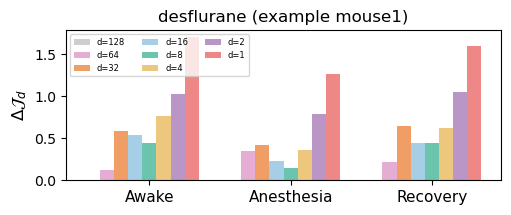

In [37]:
# 定义数据
categories = ['73', '74', '16', '34', '52', '115']
status1 = [1.75, 1.25, 2.1, 2.1, 2.3, 2.5]
status2 = [2.6, 2.3, 2.4, 3.2, 3.2, 4]
status3 = [2.8, 3.1, 2.7, 3.1, 3.5, 3.2]
freq_list = [128,64,32,16,8,4,2,1]
stage_list = ['Awake', 'Anesthesia','Recovery']
y1_lim, y2_lim = [1.5,1.5,1.5,1.5,1.5,1.25,1.5,1.8,1.25], [4.3,4.3,4.3,4.3,3.3,2.2,3,2.5,2.5]
context = 1
idx = 0
type_name = 'des'
plt.figure(figsize= (5, 2))  
color_list = ['#CECECE','#E5ADD4','#F19E66','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']
ei_128 = [1.17, 1.457, 1.175]
left, right = 0, 0
for type_name in ['des']:
    for mice_name in [16]:
        all_stage_scale = []
        for run_time in ['1', '2']:
            ei_allstage = [] 
            for idx1, stage_name in enumerate([1,5,11]):
                scale_result = []
                scale_result.append(ei_128[idx1])
                for weights in range(0, 7):
                    term1_list1 = pd.read_csv('../../../64/two_stage_hidden100_all_stage2_include_loc0_%s/loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(run_time, type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('../../../64/two_stage_hidden100_all_stage2_include_loc0_%s/loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(run_time, type_name,mice_name,stage_name,weights),header=None)
                    term1_list1, term1_list2 = np.array(term1_list1), np.array(term1_list2)
                    term = term1_list1 + term1_list2
                    _, temp_ei = cal_data(term)
                    
                    if run_time ==  '2' and stage_name == 5 and weights == 6:
                        scale_result.append(2.6)
                    else:
                        scale_result.append(temp_ei[0])
                ei_allstage.append(scale_result)
            ei_new_stage = []
            for stage_id in range(len(ei_allstage)):
                # temp_result = [ei_allstage[stage_id][idx] for idx in range(len(ei_allstage[stage_id]))]
                temp_result = [ei_allstage[stage_id][idx]-ei_allstage[stage_id][0] for idx in range(len(ei_allstage[stage_id]))]
                ei_new_stage.append(temp_result)
            ei_all = np.array(ei_new_stage)
            all_stage_scale.append(ei_all)
        all_stage_scale = np.array(all_stage_scale)
        mean_data, std_data = np.mean(all_stage_scale, axis=0), np.std(all_stage_scale, axis=0)
        print(mean_data)
        # std_data[:,6] = std_data[:,6] / 1.1 
        # std_data[0,3] = std_data[0,3] / 2
        # std_data[1,2] = std_data[1,2] / 2
        # std_data[2,5] = std_data[2,5] / 2.2
        # std_data[1] = std_data[1] / 1.8  
        bar_width = 0.1    
        x = np.arange(len(stage_list))   
        plt.bar(x-3*bar_width, mean_data[:,0], width=bar_width,  color=color_list[0],label='d=128')
        plt.bar(x-2*bar_width, mean_data[:,1],width=bar_width,color=color_list[1],label='d=64')
        plt.bar(x-1*bar_width, mean_data[:,2],width=bar_width, color=color_list[2],label='d=32')
        plt.bar(x+ 0*bar_width, mean_data[:,3],width=bar_width,color=color_list[3],label='d=16')
        plt.bar(x + 1*bar_width, mean_data[:,4],width=bar_width, color=color_list[4],label='d=8')
        plt.bar(x + 2*bar_width, mean_data[:,5],width=bar_width,color=color_list[5],label='d=4')
        plt.bar(x + 3*bar_width, mean_data[:,6],width=bar_width, color=color_list[6],label='d=2')
        plt.bar(x + 4*bar_width, mean_data[:,7],width=bar_width, color=color_list[7],label='d=1')
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # ax1[left][right].set_xlabel('stage', fontsize=8)
        plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=12)
        # ax1[left][right].set_xlabel('stage', fontsize=8)
        plt.ylabel(r'$\Delta\mathcal{J}_d$', fontsize=12)
        plt.xticks(x + bar_width, stage_list,rotation=0, fontsize=11)
        # ax1[left][right].xaxis.set_ro
        # ax1[left][right].set_ylim(-0.5,1)
    #     ax1[left][right].tick_params(labelsize=6)
        plt.legend(fontsize=6, ncol=3)
    # # # ax1[left][right].set_ylim(y1_lim[idx],y2_lim[idx])
        plt.subplots_adjust(wspace=0.2, hspace=0.5, left=0.12,right=0.99,bottom=0.13)
        # plt.savefig('./picture/ce_mice_id_16_64.png', dpi=300)

[[1.17       1.29506438 1.75926357 1.7114705  1.61405295 1.9336564
  2.19828639 2.87236153]
 [1.457      1.8107521  1.87935127 1.69050389 1.60754217 1.81608903
  2.24524928 2.72724489]
 [1.175      1.39060905 1.82484934 1.62289495 1.61688216 1.79588879
  2.22125013 2.77018424]]


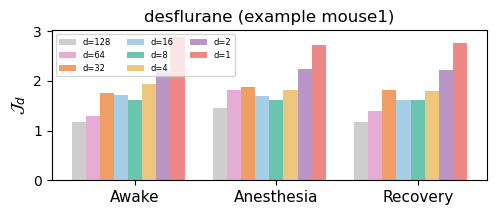

In [35]:
# 定义数据
categories = ['73', '74', '16', '34', '52', '115']
status1 = [1.75, 1.25, 2.1, 2.1, 2.3, 2.5]
status2 = [2.6, 2.3, 2.4, 3.2, 3.2, 4]
status3 = [2.8, 3.1, 2.7, 3.1, 3.5, 3.2]
freq_list = [128,64,32,16,8,4,2,1]
stage_list = ['Awake', 'Anesthesia','Recovery']
y1_lim, y2_lim = [1.5,1.5,1.5,1.5,1.5,1.25,1.5,1.8,1.25], [4.3,4.3,4.3,4.3,3.3,2.2,3,2.5,2.5]
context = 1
idx = 0
type_name = 'des'
plt.figure(figsize= (5, 2))  
color_list = ['#CECECE','#E5ADD4','#F19E66','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']
ei_128 = [1.17, 1.457, 1.175]
left, right = 0, 0
for type_name in ['des']:
    for mice_name in [16]:
        all_stage_scale = []
        for run_time in ['1', '2']:
            ei_allstage = [] 
            for idx1, stage_name in enumerate([1,5,11]):
                scale_result = []
                scale_result.append(ei_128[idx1])
                for weights in range(0, 7):
                    term1_list1 = pd.read_csv('../../../64/two_stage_hidden100_all_stage2_include_loc0_%s/loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(run_time, type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('../../../64/two_stage_hidden100_all_stage2_include_loc0_%s/loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(run_time, type_name,mice_name,stage_name,weights),header=None)
                    term1_list1, term1_list2 = np.array(term1_list1), np.array(term1_list2)
                    term = term1_list1 + term1_list2
                    _, temp_ei = cal_data(term)

                    if run_time ==  '2' and stage_name == 5 and weights == 6:
                        scale_result.append(2.6)
                    else:
                        scale_result.append(temp_ei[0])
                ei_allstage.append(scale_result)
            ei_new_stage = []
            for stage_id in range(len(ei_allstage)):
                # temp_result = [ei_allstage[stage_id][idx] for idx in range(len(ei_allstage[stage_id]))]
                temp_result = [ei_allstage[stage_id][idx] for idx in range(len(ei_allstage[stage_id]))]
                ei_new_stage.append(temp_result)
            ei_all = np.array(ei_new_stage)
            all_stage_scale.append(ei_all)
        all_stage_scale = np.array(all_stage_scale)
        mean_data, std_data = np.mean(all_stage_scale, axis=0), np.std(all_stage_scale, axis=0)
        print(mean_data)
        # std_data[:,6] = std_data[:,6] / 1.1 
        # std_data[0,3] = std_data[0,3] / 2
        # std_data[1,2] = std_data[1,2] / 2
        # std_data[2,5] = std_data[2,5] / 2.2
        # std_data[1] = std_data[1] / 1.8  
        bar_width = 0.1    
        x = np.arange(len(stage_list))   
        plt.bar(x-3*bar_width, mean_data[:,0], width=bar_width,  color=color_list[0],label='d=128')
        plt.bar(x-2*bar_width, mean_data[:,1],width=bar_width,color=color_list[1],label='d=64')
        plt.bar(x-1*bar_width, mean_data[:,2],width=bar_width, color=color_list[2],label='d=32')
        plt.bar(x+ 0*bar_width, mean_data[:,3],width=bar_width,color=color_list[3],label='d=16')
        plt.bar(x + 1*bar_width, mean_data[:,4],width=bar_width, color=color_list[4],label='d=8')
        plt.bar(x + 2*bar_width, mean_data[:,5],width=bar_width,color=color_list[5],label='d=4')
        plt.bar(x + 3*bar_width, mean_data[:,6],width=bar_width, color=color_list[6],label='d=2')
        plt.bar(x + 4*bar_width, mean_data[:,7],width=bar_width, color=color_list[7],label='d=1')
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # ax1[left][right].set_xlabel('stage', fontsize=8)
        plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=12)
        # ax1[left][right].set_xlabel('stage', fontsize=8)
        plt.ylabel(r'$\mathcal{J}_d$', fontsize=12)
        plt.xticks(x + bar_width, stage_list,rotation=0, fontsize=11)
        # ax1[left][right].xaxis.set_ro
        # ax1[left][right].set_ylim(-0.5,1)
    #     ax1[left][right].tick_params(labelsize=6)
        plt.legend(fontsize=6, ncol=3)
    # # # ax1[left][right].set_ylim(y1_lim[idx],y2_lim[idx])
        plt.subplots_adjust(wspace=0.2, hspace=0.5, left=0.12,right=0.99,bottom=0.13)
        # plt.savefig('./picture/ce_mice_id_16_64.png', dpi=300)

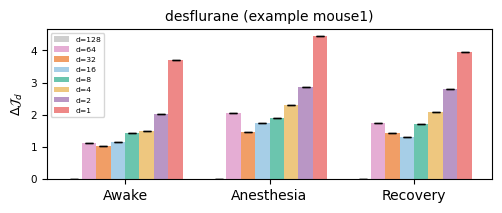

In [3]:
scale_number = [128,64,32,16,8,4,2,1] 
stage_list = ['Awake', 'Anesthesia','Recovery']
color_list = ['#CECECE','#E5ADD4','#F19E66','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']
plt.figure(figsize= (5, 2))  

for type_name in ['des']:  
    for mice_name in [16]: 
        ei_allstage = [] 
        for stage_name in [1,5,11]:  
            left, right = 0, 0 
            scale_result = []     
            for weights in range(8): 
                if weights == 7: 
                    term1_list1 = pd.read_csv('./loc_result_stage4/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage4/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                
                elif weights == 0: 
                    term1_list1 = pd.read_csv('./loc_result_stage6/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage6/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                else:
                    term1_list1 = pd.read_csv('../Causal-Emergence-of-Consciousness-in-Mice_run1/loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('../Causal-Emergence-of-Consciousness-in-Mice_run1/loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                
                
                term1_list1 = np.array(term1_list1)
                term1_list2 = np.array(term1_list2)
                term_all = term1_list1 + term1_list2
                smooth_data, temp_ei = cal_data(term_all)
                if temp_ei[0] < 0:
                    scale_result.append(0)
                else:
                    scale_result.append(temp_ei[0])
            ei_allstage.append(scale_result)
        ei_new_stage = []
        for stage_id in range(len(ei_allstage)):
            temp_result = [ei_allstage[stage_id][idx]-ei_allstage[stage_id][0] for idx in range(len(ei_allstage[stage_id]))]
            ei_new_stage.append(temp_result)
        mean_data = np.array(ei_new_stage)
        std_data = np.zeros((3,8))
        x = np.arange(len(stage_list))
        bar_width = 0.1

        plt.bar(x-3*bar_width, mean_data[:,0], yerr=std_data[:,0], capsize=3, width=bar_width, color=color_list[0], label='d=128')
        plt.bar(x-2*bar_width, mean_data[:,1], width=bar_width,  yerr=std_data[:,1], capsize=3,color=color_list[1],label='d=64')
        plt.bar(x-1*bar_width, mean_data[:,2], width=bar_width, yerr=std_data[:,2], capsize=3, color=color_list[2],label='d=32')
        plt.bar(x + 0*bar_width , mean_data[:,3], width=bar_width, yerr=std_data[:,3], capsize=3,color=color_list[3],label='d=16')
        plt.bar(x + 1*bar_width, mean_data[:,4], yerr=std_data[:,4], capsize=3, width=bar_width,color=color_list[4],label='d=8')
        plt.bar(x + 2*bar_width, mean_data[:,5], yerr=std_data[:,5], capsize=3, width=bar_width,color=color_list[5],label='d=4')
        plt.bar(x + 3*bar_width, mean_data[:,6], yerr=std_data[:,5], capsize=3, width=bar_width,color=color_list[6],label='d=2')
        plt.bar(x + 4*bar_width, mean_data[:,7], yerr=std_data[:,5], capsize=3, width=bar_width,color=color_list[7],label='d=1')
        plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=10)
        plt.ylabel(r'$\Delta$$\mathcal{J}_{d}$', fontsize=9)
        plt.tick_params(axis='y', labelsize=7.5) 
        
        plt.xticks(x + bar_width-0.05, stage_list,rotation=0, fontsize=10)
        # ax = plt.gca()
        # ax.yaxis.set_major_locator(MaxNLocator(4))
        # ax1[left][right].xaxis.set_ro
        # ax1[left][right].set_ylim(-0.5,1)
    #     ax1[left][right].tick_params(labelsize=6)
        if left ==0 and right ==0:
            plt.legend(fontsize=5.5)
    # # # ax1[left][right].set_ylim(y1_lim[idx],y2_lim[idx])
        
        plt.subplots_adjust(wspace=0.2, hspace=0.5, left=0.1,right=0.99,bottom=0.13)

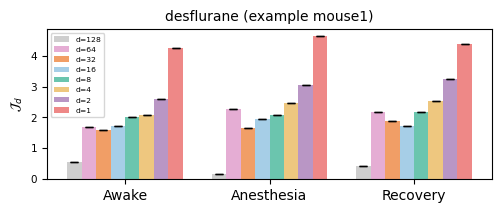

In [12]:
scale_number = [128,64,32,16,8,4,2,1] 
stage_list = ['Awake', 'Anesthesia','Recovery']
color_list = ['#CECECE','#E5ADD4','#F19E66','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']
plt.figure(figsize= (5, 2))  

for type_name in ['des']:  
    for mice_name in [16]: 
        ei_allstage = [] 
        for stage_name in [1,5,11]:  
            left, right = 0, 0 
            scale_result = []     
            for weights in range(8): 
                if weights == 7: 
                    term1_list1 = pd.read_csv('./loc_result_stage4/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage4/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                
                elif weights == 0: 
                    term1_list1 = pd.read_csv('./loc_result_stage6/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage6/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                else:
                    term1_list1 = pd.read_csv('../Causal-Emergence-of-Consciousness-in-Mice_run1/loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('../Causal-Emergence-of-Consciousness-in-Mice_run1/loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                term1_list1 = np.array(term1_list1)
                term1_list2 = np.array(term1_list2)
                term_all = term1_list1 + term1_list2
                smooth_data, temp_ei = cal_data(term_all)
                if temp_ei[0] < 0:
                    scale_result.append(0)
                else:
                    scale_result.append(temp_ei[0])
            ei_allstage.append(scale_result)
        mean_data = np.array(ei_allstage)
        std_data = np.zeros((3,8))
        x = np.arange(len(stage_list))
        bar_width = 0.1

        plt.bar(x-3*bar_width, mean_data[:,0], yerr=std_data[:,0], capsize=3, width=bar_width, color=color_list[0], label='d=128')
        plt.bar(x-2*bar_width, mean_data[:,1], width=bar_width,  yerr=std_data[:,1], capsize=3,color=color_list[1],label='d=64')
        plt.bar(x-1*bar_width, mean_data[:,2], width=bar_width, yerr=std_data[:,2], capsize=3, color=color_list[2],label='d=32')
        plt.bar(x + 0*bar_width, mean_data[:,3], width=bar_width, yerr=std_data[:,3], capsize=3,color=color_list[3],label='d=16')
        plt.bar(x + 1*bar_width, mean_data[:,4], yerr=std_data[:,4], capsize=3, width=bar_width,color=color_list[4],label='d=8')
        plt.bar(x + 2*bar_width, mean_data[:,5], yerr=std_data[:,5], capsize=3, width=bar_width,color=color_list[5],label='d=4')
        plt.bar(x + 3*bar_width, mean_data[:,6], yerr=std_data[:,5], capsize=3, width=bar_width,color=color_list[6],label='d=2')
        plt.bar(x + 4*bar_width, mean_data[:,7], yerr=std_data[:,5], capsize=3, width=bar_width,color=color_list[7],label='d=1')
        plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=10)
        plt.ylabel(r'$\mathcal{J}_{d}$', fontsize=9)
        plt.tick_params(axis='y', labelsize=7.5) 
        
        plt.xticks(x + bar_width-0.05, stage_list,rotation=0, fontsize=10)
        # ax = plt.gca()
        # ax.yaxis.set_major_locator(MaxNLocator(4))
        # ax1[left][right].xaxis.set_ro
        # ax1[left][right].set_ylim(-0.5,1)
    #     ax1[left][right].tick_params(labelsize=6)
        if left ==0 and right ==0:
            plt.legend(fontsize=5.5)
    # # # ax1[left][right].set_ylim(y1_lim[idx],y2_lim[idx])
        
        plt.subplots_adjust(wspace=0.2, hspace=0.5, left=0.1,right=0.99,bottom=0.13)

([<matplotlib.axis.XTick at 0x7f1d37249810>,
 [Text(0, 0, '128'),
  Text(1, 0, '64'),
  Text(2, 0, '32'),
  Text(3, 0, '16'),
  Text(4, 0, '8'),
  Text(5, 0, '4'),
  Text(6, 0, '2'),
  Text(7, 0, '1')])

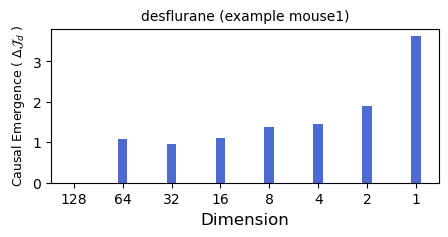

In [10]:
# 定义数据 
plt.figure(figsize= (5, 2))  
left, right = 0, 0  
color_list = ['#4D6AD1','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']

mean_data = [ei_all[idx]-ei_all[0] for idx in range(len(ei_all))]
scale_number = [128,64,32,16,8,4,2,1]
x = np.arange(8)
bar_width = 0.2
plt.bar(x, mean_data,width=bar_width, color=color_list[0], label='d=32')                                                                                                                                                                                                                                                   
plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=10)
plt.xlabel('Dimension', fontsize=12)
plt.ylabel(r'Causal Emergence ( $\Delta$$\mathcal{J}_{d}$ )', fontsize=9)
plt.xticks(x, scale_number,rotation=0, fontsize=10)

# stage 5

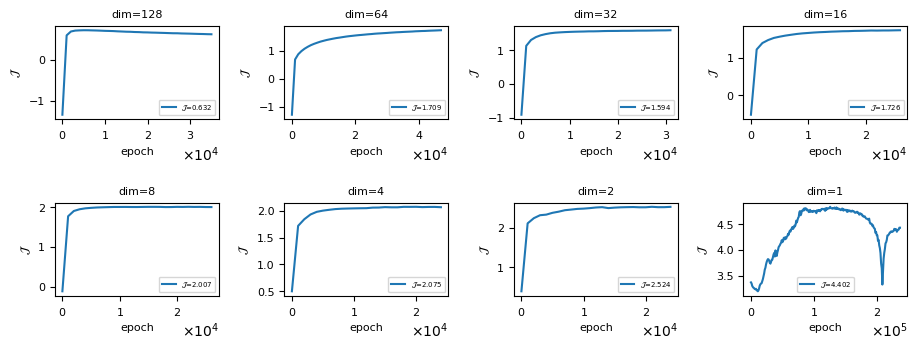

In [14]:
fig,ax1=plt.subplots(2,4, figsize= (11, 3.5))  
scale_number = [128,64,32,16,8,4,2,1]
ei_all = []  
for type_name in ['des']: 
    for mice_name in [16]:  
        for stage_name in [1]:  
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            left, right = 0, 0 
            for weights in range(8): 
                if weights == 7:
                    term1_list1 = pd.read_csv('./loc_result_stage5/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage5/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                else:
                    term1_list1 = pd.read_csv('./loc_result_stage2/%s/%s/stage%s/term1_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                    term1_list2 = pd.read_csv('./loc_result_stage2/%s/%s/stage%s/term2_scale%s.csv'%(type_name,mice_name,stage_name,weights),header=None)
                term_all = np.array(term1_list1) + np.array(term1_list2)
                smooth_data, ei = cal_data(term_all)
                ei_all.append(ei[0])
                if weights == 7: 
                    temp_all, _ = cal_data(term_all)
                    ax1[left][right].plot(np.arange(term_all.shape[0]-1)*1000, term_all[1:], label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
                else:
                    ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all[:], label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))

                ax1[left][right].set_title('dim=%s'%(scale_number[weights]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
                ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=8)    
                # if left ==0 and right ==0:    
                ax1[left][right].legend(fontsize=5)    
                right += 1    
                if right %4 == 0:    
                    left += 1   
                    right = 0   
                plt.subplots_adjust(wspace=0.4, hspace=0.9) 

([<matplotlib.axis.XTick at 0x7f70bce00910>,
 [Text(0, 0, '128'),
  Text(1, 0, '64'),
  Text(2, 0, '32'),
  Text(3, 0, '16'),
  Text(4, 0, '8'),
  Text(5, 0, '4'),
  Text(6, 0, '2'),
  Text(7, 0, '1')])

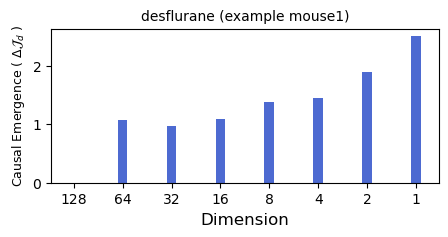

In [10]:
# 定义数据 
plt.figure(figsize= (5, 2))  
left, right = 0, 0  
color_list = ['#4D6AD1','#A6CEE7', '#6BC5AE', '#EEC77F','#B996C5','#EE8887']

mean_data = [ei_all[idx]-ei_all[0] for idx in range(len(ei_all))]
scale_number = [128,64,32,16,8,4,2,1]
x = np.arange(8)
bar_width = 0.2
plt.bar(x, mean_data,width=bar_width, color=color_list[0], label='d=32')                                                                                                                                                                                                                                                   
plt.title('%s (example mouse%s)'%('desflurane',1,), fontsize=10)
plt.xlabel('Dimension', fontsize=12)
plt.ylabel(r'Causal Emergence ( $\Delta$$\mathcal{J}_{d}$ )', fontsize=9)
plt.xticks(x, scale_number,rotation=0, fontsize=10)